In [1]:
# Part A: Understanding the Dataset

In [5]:
# Q1. Dataset Overview
# Load the dataset and answer the following:
from google.colab import files
uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [6]:
import pandas as pd
agri_df = pd.read_csv("agriculture_yield_dataset.csv")

In [7]:
# How many rows and columns are present?
print("Shape:", agri_df.shape)

Shape: (1500, 8)


In [8]:
# What are the names of all columns?
print("Columns:")
print(agri_df.columns.tolist())

Columns:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


In [9]:
# Display the first 10 records.
print("First 10 rows:")
print(agri_df.head(10))

First 10 rows:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   

  crop_type soil_type  yield_ton_per_hectare  
0     Maize     Loamy                   5.92  
1     Maize     Sandy                   6.24  
2     Wheat     Sa

In [11]:
# Q2. Data Types and Missing Values

In [12]:
# Check the data type of each column.
print(agri_df.dtypes)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object


In [13]:
# Identify whether any missing values are present.
print(agri_df.isnull().sum())

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [14]:
# If missing values exist, mention the affected columns.
missing_cols = agri_df.columns[agri_df.isnull().sum() > 0]
print("Columns with Missing Values:")
print(missing_cols.tolist())

Columns with Missing Values:
[]


In [15]:
# Q3. Descriptive Statistics

In [16]:
# Generate summary statistics for all numerical features and answer:
agri_df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [20]:
# Which feature has the highest mean value?
agri_df.describe().loc["mean"].idxmax()

'rainfall_mm'

In [23]:
# Which feature has the highest standard deviation?
agri_df.describe().loc["std"].idxmax()

'rainfall_mm'

In [24]:
# Part B: Exploratory Data Analysis (EDA)

In [25]:
# Q4. Distribution Analysis
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Create histograms for:

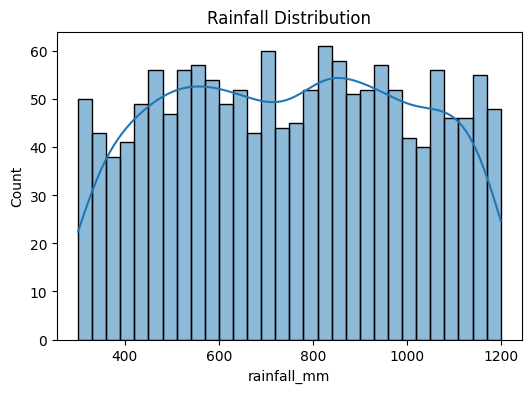

In [27]:
# rainfall_mm
plt.figure(figsize=(6,4))
sns.histplot(agri_df['rainfall_mm'], bins=30, kde=True)
plt.title("Rainfall Distribution")
plt.show()

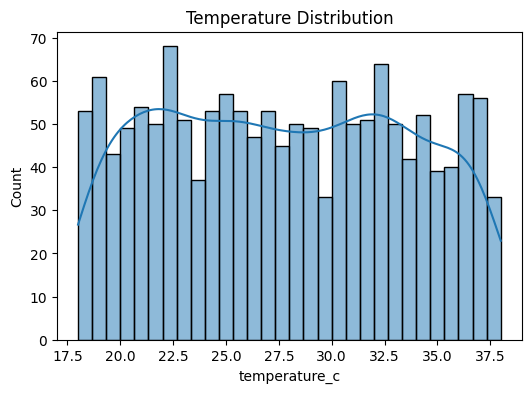

In [28]:
# temperature_c
plt.figure(figsize=(6,4))
sns.histplot(agri_df['temperature_c'], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.show()

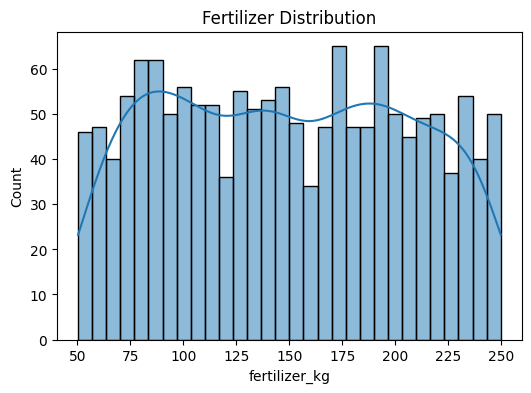

In [29]:
# fertilizer_kg
plt.figure(figsize=(6,4))
sns.histplot(agri_df['fertilizer_kg'], bins=30, kde=True)
plt.title("Fertilizer Distribution")
plt.show()

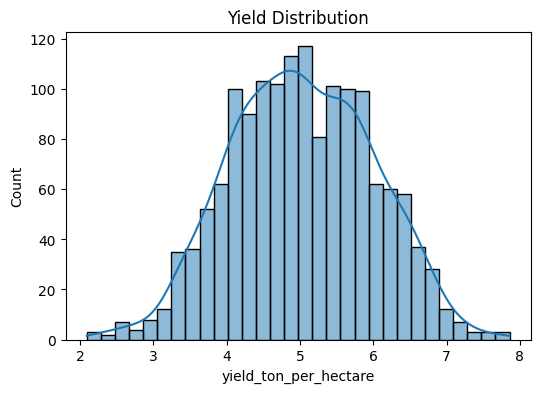

In [30]:
# yield_ton_per_hectare
plt.figure(figsize=(6,4))
sns.histplot(agri_df['yield_ton_per_hectare'], bins=30, kde=True)
plt.title("Yield Distribution")
plt.show()

WRITE 2-3 OBSERVATIONS FROM EACH HISTOGRAM

1. RAINFALL
-> Data is spread across a wide range.
-> Slight skewness present (not perfectly normal).
-> Few high rainfall values act as extreme points.

2. TEMPERATURE
-> Mostly concentrated in a mid-range (balanced distribution).
-> Slight bell-shaped curve visible.
-> Very few extreme low/high temperatures.

3. FERTILIZER
-> Right-skewed distribution (more low-to-medium values).
-> Few high fertilizer usage outliers.
-> Most farmers use moderate fertilizer amounts.

4. YIELD
-> Almost normal but slightly skewed.
-> Most values lie in a central range.
-> Some high-yield outliers are present.

In [31]:
# Q5. Crop Type Analysis

In [32]:
# Find the number of records for each crop type
agri_df['crop_type'].value_counts()

,count
crop_type,
Cotton,311
Soybean,306
Wheat,303
Rice,293
Maize,287


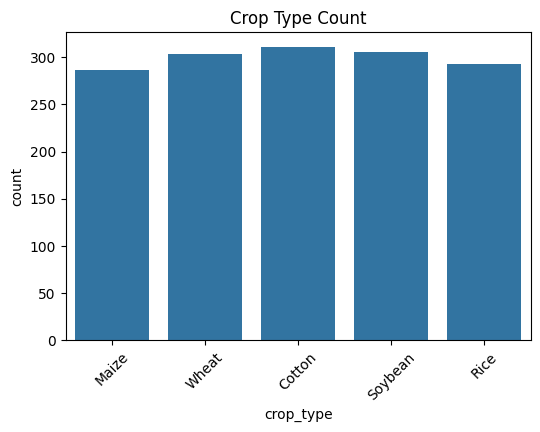

In [33]:
# Create a count plot (bar chart) for crop_type
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=agri_df, x='crop_type')
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

In [34]:
# Which crop appears most frequently?
agri_df['crop_type'].value_counts().idxmax()

'Cotton'

In [35]:
# Q6. Soil Type Analysis

In [36]:
# Frequency of each soil type
agri_df['soil_type'].value_counts()

,count
soil_type,
Clay,534
Sandy,492
Loamy,474


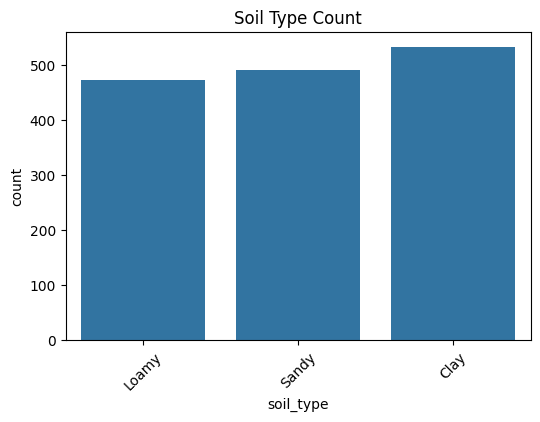

In [37]:
# Count plot for soil_type
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=agri_df, x='soil_type')
plt.title("Soil Type Count")
plt.xticks(rotation=45)
plt.show()

In [38]:
# Which soil type is most common?
agri_df['soil_type'].value_counts().idxmax()

'Clay'

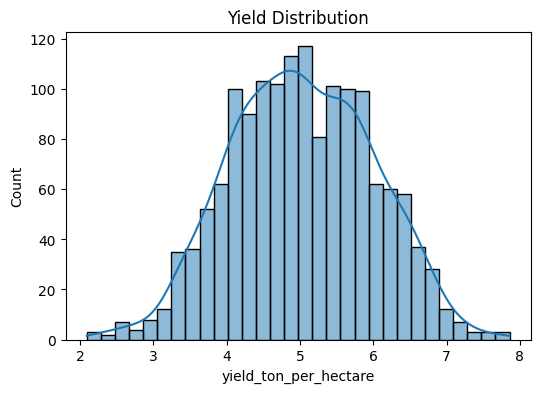

In [39]:
# Q7. Yield Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(agri_df['yield_ton_per_hectare'], bins=30, kde=True)
plt.title("Yield Distribution")
plt.show()

In [40]:
# Basic stats to support interpretation
agri_df['yield_ton_per_hectare'].describe()

,yield_ton_per_hectare
count,1500.000000
mean,5.028793
std,0.968282
min,2.090000
25%,4.337500
50%,5.010000
75%,5.740000
max,7.860000


Q. IS THE DISTRIBUTION APPROXIMATELY NORMAL?
A. Yes, it is roughly bell-shaped with most values concentrated around the center, but not perfectly normal.
Q. ARE THERE ANY NOTICEABLE OUTLIERS?
A. Yes, a few unusually high yield values appear far from the main cluster, indicating possible outliers.

In [41]:
# Q8. Scatter Plot Analysis
import matplotlib.pyplot as plt
import seaborn as sns

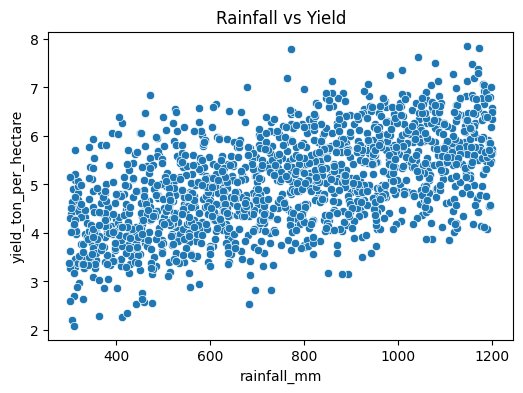

In [42]:
# Create scatter plot of rainfall_mm vs yield_ton_per_hectare
plt.figure(figsize=(6,4))
sns.scatterplot(data=agri_df, x='rainfall_mm', y='yield_ton_per_hectare')
plt.title("Rainfall vs Yield")
plt.show()

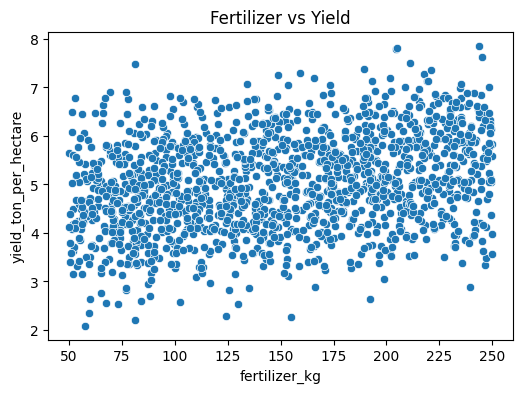

In [43]:
# Create scatter plot of fertilizer_kg vs yield_ton_per_hectare
plt.figure(figsize=(6,4))
sns.scatterplot(data=agri_df, x='fertilizer_kg', y='yield_ton_per_hectare')
plt.title("Fertilizer vs Yield")
plt.show()

Q. BASED ON THE PLOTS, WHICH FEATURE APPEARS TO HAVE A STRONGER RELATIONSHIP WITH YIELD?
A. fertilizer_kg. This is because the scatter plot of fertilizer shows a clearer upward/downward pattern compared to rainfall, which appears more scattered and less structured.

In [44]:
# Q9. Correlation Analysis
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Generate a correlation matrix for numerical features.
corr_matrix = agri_df.corr(numeric_only=True)
corr_matrix

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


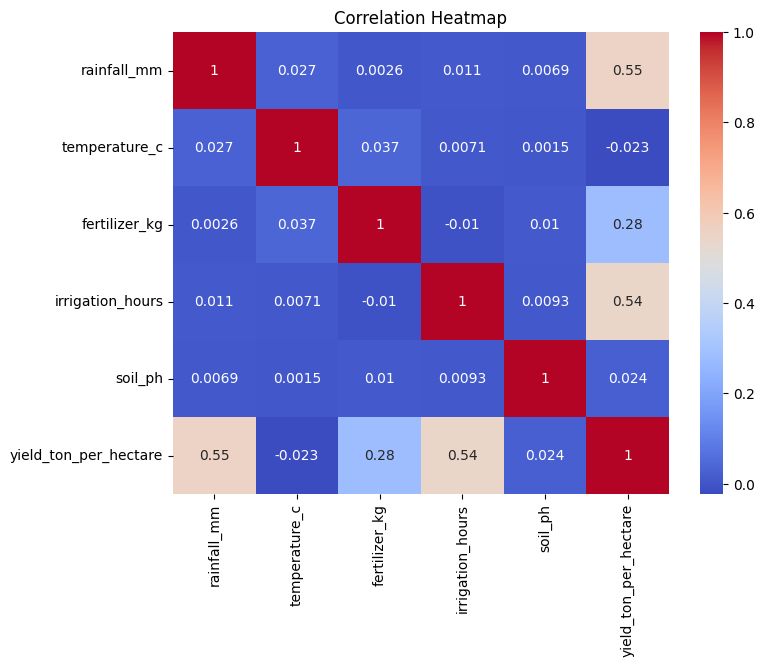

In [46]:
# Create a heatmap.
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [47]:
# Identify the top three features most correlated with crop yield.
corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)

,yield_ton_per_hectare
yield_ton_per_hectare,1.000000
rainfall_mm,0.553704
irrigation_hours,0.542664
fertilizer_kg,0.278043
soil_ph,0.024412
temperature_c,-0.022559


In [48]:
# Q10. Group-Based Analysis

In [49]:
# Average yield for each crop type
agri_df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

,yield_ton_per_hectare
crop_type,
Rice,5.494744
Soybean,5.173431
Wheat,4.989472
Maize,4.897143
Cotton,4.607299


In [50]:
# Average yield for each soil type
agri_df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

,yield_ton_per_hectare
soil_type,
Loamy,5.366519
Clay,5.134326
Sandy,4.588882


In [52]:
# Which crop has highest average yield?
agri_df.groupby('crop_type')['yield_ton_per_hectare'].mean().idxmax()

'Rice'

In [53]:
# Which soil type has highest average yield?
agri_df.groupby('soil_type')['yield_ton_per_hectare'].mean().idxmax()

'Loamy'

In [54]:
# Part C: Data Preparation

In [55]:
# Q11. Feature Encoding
# The dataset contains categorical variables.

In [56]:
# Identify the categorical columns.
cat_cols = agri_df.select_dtypes(include='object').columns
cat_cols

Index(['crop_type', 'soil_type'], dtype='object')

In [58]:
# Convert them into numerical form using One-Hot Encoding.
agri_encoded = pd.get_dummies(agri_df, columns=cat_cols, drop_first=True)

In [59]:
# Display the first five rows of the transformed dataset.
agri_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [60]:
# Q12. Feature Selection

In [61]:
# Separate:
# Input features (X)
X = agri_encoded.drop('yield_ton_per_hectare', axis=1)
# Target variable (y)
y = agri_encoded['yield_ton_per_hectare']

In [62]:
# Specify which column is being used as the target variable.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1500, 11)
y shape: (1500,)


Q. Specify which column is being used as the target variable.

A. yield_ton_per_hectare

In [63]:
# Part D: Machine Learning

In [64]:
# Q13. Train-Test Split

In [65]:
# Split the dataset into:
# 80% Training Data
# 20% Testing Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
# Display the shape of:
# X_train
print("X_train shape:", X_train.shape)
# X_test
print("X_test shape:", X_test.shape)
# y_train
print("y_train shape:", y_train.shape)
# y_test
print("y_test shape:", y_test.shape)

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


In [73]:
#Q14. Linear Regression Model
from sklearn.linear_model import LinearRegression

In [74]:
# Train a Linear Regression model.
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [75]:
# Display the model coefficients and intercept.
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("Intercept:", model.intercept_)
print("\nCoefficients:")
print(coeff_df)

Intercept: 1.587132027736121

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933


In [77]:
# Which feature has the highest positive coefficient?
highest_feature = coeff_df.loc[coeff_df["Coefficient"].idxmax()]
print("Feature with highest positive coefficient:")
print(highest_feature)

Feature with highest positive coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
